# par_to_poni — Modern vs Classic pyFAI

**Author:** DeepSeek V4 Pro (opencode), June 2026

Synthetic CeO2 powder image on an Eiger4M detector, integrated three ways:

1.  **ImageD11** native geometry (`compute_tth_eta`) — reference
2.  **Modern pyFAI** — orientation chosen per flip (correct for Eiger4M:
    `(−1,0,0,−1)` → orient 2)
3.  **Classic pyFAI** — `force_orient3=True` for old pyFAI that only
    accepts orientation 3 (no pixel flips)

Each case gets its own 1D + 2D figure.

In [1]:
import numpy as np, matplotlib.pyplot as plt
%matplotlib inline
import par_to_poni as pp
from ImageD11.transform import compute_tth_eta
from pyFAI import detector_factory
from pyFAI.integrator.azimuthal import AzimuthalIntegrator

## 1. Geometry & synthetic image

In [2]:
# --- Eiger4M detector ---
det = detector_factory("Eiger4M")
mask = det.mask;  mask_bool = mask.astype(bool);  shape = det.shape
print(f"Eiger4M: {shape}, pixel={det.pixel1*1e6:.0f} µm, "
      f"gap px={mask.sum():,} / {mask.size:,}")

# --- ImageD11 par ---
par = {
    "distance": 0.5, "y_center": 123.0, "z_center": 456.0,
    "y_size": 75e-6, "z_size": 75e-6,
    "tilt_x": 0.04, "tilt_y": 0.03, "tilt_z": 0.02,
    "o11": -1, "o12": 0, "o21": 0, "o22": -1,   # Eiger4M
    "wavelength": 0.31e-10, "wedge": 0.0, "chi": 0.0, "omegasign": 1.0,
}
print(f"Flip ({par['o11']},{par['o22']}) → orient "
      f"{pp.flip_to_orientation(par['o11'],par['o12'],par['o21'],par['o22'])}")

# --- CeO2 peaks (Fm-3m, a=5.411 Å) ---
def ceo2_peaks(wl_m, max_tth=0.30):
    a = 5.411;  wl_A = wl_m * 1e10
    peaks = [];  seen = set()
    for n in range(3, 28):
        d = a / np.sqrt(n)
        sth = wl_A / (2 * d)
        if sth >= 1.0: continue
        tth = 2 * np.arcsin(sth)
        if tth > max_tth: continue
        key = None
        for h in range(6):
            for k in range(6):
                for l in range(6):
                    if h*h+k*k+l*l != n: continue
                    if (h%2,k%2,l%2) not in ((0,0,0),(1,1,1)): continue
                    kk = tuple(sorted((h,k,l)))
                    if kk in seen: continue
                    key = kk; break
                if key: break
            if key: break
        if key is None: continue
        seen.add(key)
        peaks.append((f"({key[0]}{key[1]}{key[2]})", d, tth))
    return sorted(peaks, key=lambda x: x[2])

peaks = ceo2_peaks(par["wavelength"])
print(f"CeO2 peaks: {len(peaks)} up to 2θ={np.degrees(peaks[-1][2]):.1f}°")

# --- Tth/eta image via ImageD11 ---
s0, s1 = shape
sc, fc = np.meshgrid(np.arange(s0, dtype=np.float64),
                     np.arange(s1, dtype=np.float64), indexing="ij")
pid = {k: v for k, v in par.items() if k != "fit_tolerance"}
pid["wavelength"] = par["wavelength"] * 1e10
tth_d, eta_d = compute_tth_eta((sc.ravel(), fc.ravel()), **pid)
tth_deg = tth_d.reshape(shape);  eta_deg = eta_d.reshape(shape)
tth_rad = np.radians(tth_deg)

# --- Build CeO2 image ---
rng = np.random.RandomState(42)
sigma = 0.0012
scales = {"(111)":1.0,"(200)":0.15,"(220)":0.55,"(311)":0.40,
          "(222)":0.10,"(400)":0.20,"(331)":0.25,"(420)":0.15}
img = np.zeros(shape, dtype=np.float64)
for hkl, d, ti in peaks:
    img += scales.get(hkl, 0.3) * np.exp(-0.5 * ((tth_rad - ti) / sigma) ** 2)
img += np.maximum(0.02*(1 + 0.1*rng.randn(*shape)), 0)
img = rng.poisson(np.maximum(img*500, 0)).astype(np.float64)
img[np.where(mask_bool)] = np.nan
img_pyfai = np.where(np.isnan(img), 0, img)
valid = ~np.isnan(img)

vlo, vhi = np.nanpercentile(img, [2, 98])
print(f"Image: {valid.sum():,} valid px, range [{vlo:.0f}, {vhi:.0f}] counts")

Eiger4M: (2167, 2070), pixel=75 µm, gap px=250,330 / 4,485,690
Flip (-1,-1) → orient 2
CeO2 peaks: 10 up to 2θ=17.1°


Image: 4,235,360 valid px, range [4, 162] counts


## 2. ImageD11 reference

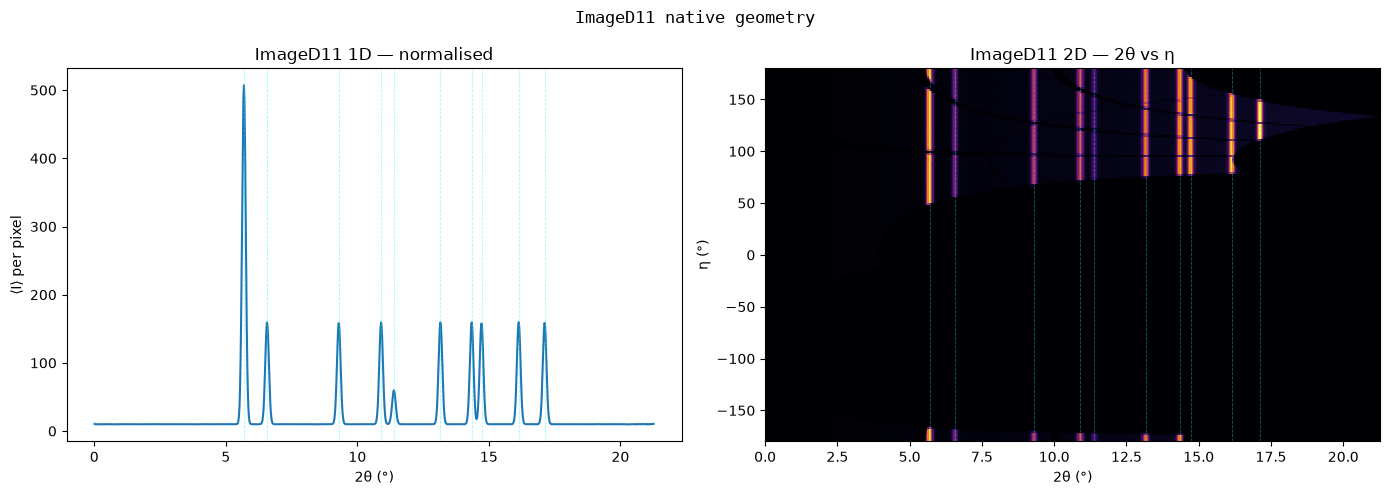

In [3]:
# Normalised 1D: ΣI / count per 2θ bin
n_rad, n_azi = 1000, 360
tth_f = tth_deg[valid];  eta_f = eta_deg[valid];  img_f = img[valid]
edges_1d = np.linspace(tth_f.min(), tth_f.max(), n_rad + 1)
center_1d = 0.5 * (edges_1d[:-1] + edges_1d[1:])
sum_I, _ = np.histogram(tth_f, bins=edges_1d, weights=img_f)
cnt,    _ = np.histogram(tth_f, bins=edges_1d)
hist_norm = sum_I / np.maximum(cnt, 1)

# 2D histogram
hist_2d, tth_e, eta_e = np.histogram2d(
    tth_f, eta_f, bins=[n_rad//2, n_azi//2], weights=img_f)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(center_1d, hist_norm)
for _, _, ti in peaks: ax1.axvline(np.degrees(ti), color='cyan', ls='--', alpha=0.4, lw=0.6)
ax1.set(xlabel="2θ (°)", ylabel="⟨I⟩ per pixel", title="ImageD11 1D — normalised")
ax2.pcolormesh(tth_e, eta_e, hist_2d.T, cmap="inferno", shading="auto")
for _, _, ti in peaks: ax2.axvline(np.degrees(ti), color='cyan', ls='--', alpha=0.4, lw=0.6)
ax2.set(xlabel="2θ (°)", ylabel="η (°)", title="ImageD11 2D — 2θ vs η")
fig.suptitle("ImageD11 native geometry", fontsize=12, fontfamily="monospace")
fig.tight_layout();  plt.show()

## 3. Modern pyFAI — correct flip for Eiger4M

Modern:  orient=2  dist=0.4997  rot=(-0.0200,0.0300,0.0400)
Detector Detector	 PixelSize= 75µm, 75µm	 TopRight (2)
Wavelength= 0.310000 Å
SampleDetDist= 4.996751e-01 m	PONI= 1.132897e-01, -7.323340e-04 m	rot1=-0.020000  rot2=0.030000  rot3=0.040000 rad
DirectBeamDist= 500.000 mm	Center: x=123.500, y=1710.500 pix	Tilt= 2.066° tiltPlanRotation= 56.320° λ= 0.310Å


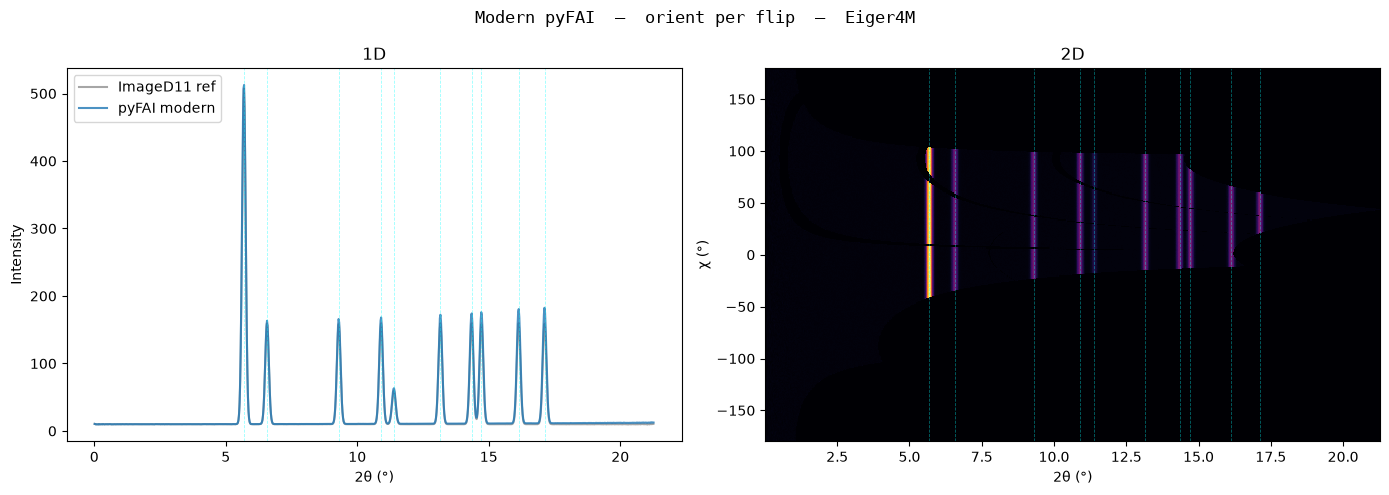

In [4]:
par_eiger = dict(par)
poni_mod = pp.par_to_poni(par_eiger, detector_shape=shape)
print(f"Modern:  orient={poni_mod['orientation']}  "
      f"dist={poni_mod['dist']:.4f}  "
      f"rot=({poni_mod['rot1']:.4f},{poni_mod['rot2']:.4f},{poni_mod['rot3']:.4f})")
print(repr(AzimuthalIntegrator(
    dist=poni_mod["dist"], poni1=poni_mod["poni1"], poni2=poni_mod["poni2"],
    rot1=poni_mod["rot1"], rot2=poni_mod["rot2"], rot3=poni_mod["rot3"],
    pixel1=poni_mod["pixel1"], pixel2=poni_mod["pixel2"],
    wavelength=poni_mod["wavelength"], orientation=poni_mod["orientation"])))

ai_mod = AzimuthalIntegrator(
    dist=poni_mod["dist"], poni1=poni_mod["poni1"], poni2=poni_mod["poni2"],
    rot1=poni_mod["rot1"], rot2=poni_mod["rot2"], rot3=poni_mod["rot3"],
    pixel1=poni_mod["pixel1"], pixel2=poni_mod["pixel2"],
    wavelength=poni_mod["wavelength"], orientation=poni_mod["orientation"])
ai_mod.detector.shape = shape

r1d = ai_mod.integrate1d(img_pyfai, npt=n_rad, mask=mask.astype(np.int8),
                         method="splitpixel", unit="2th_deg")
r2d = ai_mod.integrate2d(img_pyfai, npt_rad=n_rad, npt_azim=n_azi,
                         mask=mask.astype(np.int8), method="splitpixel",
                         unit="2th_deg")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(center_1d, hist_norm, 'k-', alpha=0.35, lw=1.5, label="ImageD11 ref")
ax1.plot(r1d.radial, r1d.intensity, alpha=0.8, label="pyFAI modern")
for _, _, ti in peaks: ax1.axvline(np.degrees(ti), color='cyan', ls='--', alpha=0.4, lw=0.6)
ax1.set(xlabel="2θ (°)", ylabel="Intensity", title="1D")
ax1.legend()
ax2.pcolormesh(r2d.radial, r2d.azimuthal, r2d.intensity, cmap="inferno", shading="auto")
for _, _, ti in peaks: ax2.axvline(np.degrees(ti), color='cyan', ls='--', alpha=0.4, lw=0.6)
ax2.set(xlabel="2θ (°)", ylabel="χ (°)", title="2D")
fig.suptitle("Modern pyFAI  —  orient per flip  —  Eiger4M", fontsize=12, fontfamily="monospace")
fig.tight_layout();  plt.show()

## 4. Classic pyFAI — forced orientation 3 (old pyFAI, no flips)

Classic: orient=3  dist=0.4997  rot=(-0.0200,-0.0300,-0.0400)
  stored flip: o11=-1, o22=-1
Detector Detector	 PixelSize= 75µm, 75µm	 BottomRight (3)
Wavelength= 0.310000 Å
SampleDetDist= 4.996751e-01 m	PONI= 4.923525e-02, -7.323340e-04 m	rot1=-0.020000  rot2=-0.030000  rot3=-0.040000 rad
DirectBeamDist= 500.000 mm	Center: x=123.500, y=456.500 pix	Tilt= 2.066° tiltPlanRotation= -56.320° λ= 0.310Å


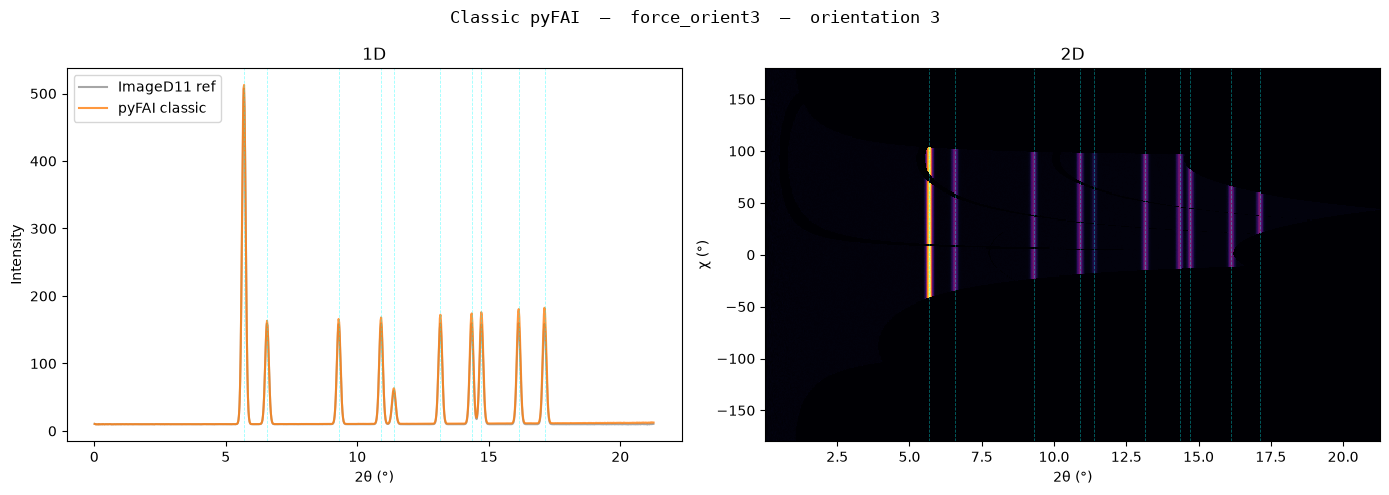

In [5]:
poni_cl = pp.par_to_poni(par_eiger, detector_shape=shape, force_orient3=True)
print(f"Classic: orient={poni_cl['orientation']}  "
      f"dist={poni_cl['dist']:.4f}  "
      f"rot=({poni_cl['rot1']:.4f},{poni_cl['rot2']:.4f},{poni_cl['rot3']:.4f})")
print(f"  stored flip: o11={poni_cl['_forward_o11']}, o22={poni_cl['_forward_o22']}")
print(repr(AzimuthalIntegrator(
    dist=poni_cl["dist"], poni1=poni_cl["poni1"], poni2=poni_cl["poni2"],
    rot1=poni_cl["rot1"], rot2=poni_cl["rot2"], rot3=poni_cl["rot3"],
    pixel1=poni_cl["pixel1"], pixel2=poni_cl["pixel2"],
    wavelength=poni_cl["wavelength"], orientation=poni_cl["orientation"])))

ai_cl = AzimuthalIntegrator(
    dist=poni_cl["dist"], poni1=poni_cl["poni1"], poni2=poni_cl["poni2"],
    rot1=poni_cl["rot1"], rot2=poni_cl["rot2"], rot3=poni_cl["rot3"],
    pixel1=poni_cl["pixel1"], pixel2=poni_cl["pixel2"],
    wavelength=poni_cl["wavelength"], orientation=poni_cl["orientation"])
ai_cl.detector.shape = shape

r1d = ai_cl.integrate1d(img_pyfai, npt=n_rad, mask=mask.astype(np.int8),
                        method="splitpixel", unit="2th_deg")
r2d = ai_cl.integrate2d(img_pyfai, npt_rad=n_rad, npt_azim=n_azi,
                        mask=mask.astype(np.int8), method="splitpixel",
                        unit="2th_deg")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(center_1d, hist_norm, 'k-', alpha=0.35, lw=1.5, label="ImageD11 ref")
ax1.plot(r1d.radial, r1d.intensity, alpha=0.8, color='tab:orange',
         label="pyFAI classic")
for _, _, ti in peaks: ax1.axvline(np.degrees(ti), color='cyan', ls='--', alpha=0.4, lw=0.6)
ax1.set(xlabel="2θ (°)", ylabel="Intensity", title="1D")
ax1.legend()
ax2.pcolormesh(r2d.radial, r2d.azimuthal, r2d.intensity, cmap="inferno", shading="auto")
for _, _, ti in peaks: ax2.axvline(np.degrees(ti), color='cyan', ls='--', alpha=0.4, lw=0.6)
ax2.set(xlabel="2θ (°)", ylabel="χ (°)", title="2D")
fig.suptitle("Classic pyFAI  —  force_orient3  —  orientation 3", fontsize=12, fontfamily="monospace")
fig.tight_layout();  plt.show()

## 5. Round-trip verification

The classic orientation 3 poni must round‑trip back to the original
ImageD11 flip `(−1,0,0,−1)`.  `poni_to_par` reads the stored metadata
and reverses the compensation automatically.

In [6]:
# Round-trip from classic orient=3 poni back to ImageD11 par
par_rt = pp.poni_to_par(poni_cl, detector_shape=shape)
print("Round-trip from classic (orient=3) poni → par:")
for k in ["o11","o12","o21","o22","tilt_x","tilt_y","tilt_z","distance","y_center","z_center"]:
    orig = par_eiger[k];  rec = par_rt[k]
    ok = "✓" if abs(orig-rec) < 1e-10 else "✗"
    print(f"  {k:>10s}: {orig} → {rec} {ok}")
print()

# Also check via file I/O
import tempfile, os
with tempfile.TemporaryDirectory() as d:
    pf = os.path.join(d, "test_f3.poni")
    pp.write_poni(poni_cl, pf)
    poni_r = pp.read_poni(pf)
    par_r = pp.poni_to_par(poni_r, detector_shape=shape)
    print("Via file I/O:")
    for k in ["o11","o22","tilt_x","tilt_y","tilt_z","distance"]:
        orig = par_eiger[k];  rec = par_r[k]
        ok = "✓" if abs(orig-rec) < 1e-10 else "✗"
        print(f"  {k:>10s}: {orig} → {rec} {ok}")

Round-trip from classic (orient=3) poni → par:
         o11: -1 → -1 ✓
         o12: 0 → 0 ✓
         o21: 0 → 0 ✓
         o22: -1 → -1 ✓
      tilt_x: 0.04 → 0.04 ✓
      tilt_y: 0.03 → 0.03 ✓
      tilt_z: 0.02 → 0.02 ✓
    distance: 0.5 → 0.5 ✓
    y_center: 123.0 → 123.00000000000001 ✓
    z_center: 456.0 → 455.9999999999999 ✓

Via file I/O:
         o11: -1 → -1 ✓
         o22: -1 → -1 ✓
      tilt_x: 0.04 → 0.04 ✓
      tilt_y: 0.03 → 0.03 ✓
      tilt_z: 0.02 → 0.02 ✓
    distance: 0.5 → 0.4999999999999921 ✓
